### 1. Import Libraries
We import TensorFlow and other helper libraries for model building, data manipulation, and visualization. We specifically use the pre-trained **VGG16** model as our feature extractor to leverage its deep hierarchical understanding of visual patterns.

In [1]:
import os
import pickle
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix


# Set seed for reproducibility in manufacturing audits
tf.random.set_seed(42)

### 2. Data Loading & Preprocessing
Using `image_dataset_from_directory`, we load our surface defect images. We also apply `.prefetch()` and `.cache()` to optimize training performance, allowing the CPU to prepare the next batch while the GPU is training.

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/data/neu_surface_defects'

# Load datasets from directory
class_names = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path, # Path to your NEU dataset
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(200, 200),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(200, 200),
    batch_size=32,
    label_mode='categorical'
)

# Performance optimization: Prefetching and Caching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Mounted at /content/drive
Found 1800 files belonging to 6 classes.
Using 1440 files for training.
Found 1800 files belonging to 6 classes.
Using 360 files for validation.


### 3. Exploratory Data Analysis (EDA)
Visualizing a sample of the training data ensures that the labels (Defect Types) are correctly mapped and the images are loaded as expected. This step is crucial for verifying the quality of our ground-truth data.

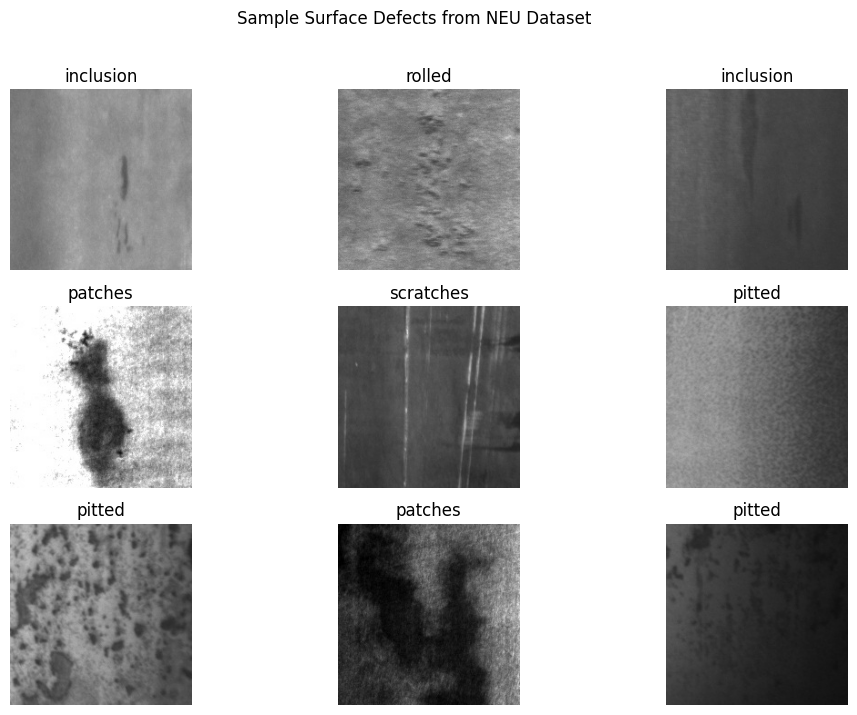

In [3]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Surface Defects from NEU Dataset")
plt.show()

### 4. Data Augmentation & Preprocessing
To prevent overfitting on our industrial dataset, we implement **Data Augmentation**. We also apply VGG16-specific preprocessing via a Lambda layer to align our pixel values with the ImageNet distribution.

In [4]:
# Augmentation pipeline to simulate production line variations
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.2)
])

# VGG16 Preprocessing Layer (Mean subtraction, BGR conversion)
preprocess_layer = layers.Lambda(preprocess_input)

### 5. Build Transfer Learning Model
We implement **Transfer Learning** by leveraging a pre-trained VGG16 base with frozen weights. To optimize for surface defect classification, we added a custom head featuring **Global Average Pooling** and **Dropout** for robust regularization.

In [5]:
# Base model: VGG16 pre-trained on ImageNet
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(200, 200, 3))

# [Advanced Insight] Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Construct the full model
model = models.Sequential([
    layers.Input(shape=(200, 200, 3)),
    data_augmentation,
    preprocess_layer,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Crucial for small industrial datasets
    layers.Dense(6, activation='softmax') # 6 defect categories
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### 6. Training Model
The model is trained to identify complex surface textures. We monitor convergence to ensure the loss decreases steadily, indicating the model is effectively learning the 'Reason Codes' for different defects.

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # Short training for local/Colab efficiency
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.3236 - loss: 1.7442 - val_accuracy: 0.6333 - val_loss: 1.0931
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.5951 - loss: 1.0667 - val_accuracy: 0.9083 - val_loss: 0.5283
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 0.8014 - loss: 0.5772 - val_accuracy: 0.9639 - val_loss: 0.1866
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.9104 - loss: 0.2703 - val_accuracy: 0.9722 - val_loss: 0.0973
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9465 - loss: 0.1708 - val_accuracy: 0.9889 - val_loss: 0.0468
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.9639 - loss: 0.1205 - val_accuracy: 0.9833 - val_loss: 0.0415
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9757 - loss: 0.0843 - val_accuracy: 0.9917 - val_loss: 0.0279
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.9806 - loss: 0.0699 - val_accuracy: 0.9

### 7. Model Evaluation & Visualization
In a manufacturing context, we focus on the **Confusion Matrix** to ensure high-risk defects (like 'Scratches') are not misclassified as 'Normal' surfaces. This audit provides transparency for Quality Assurance (QA) teams.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
### Manufacturing Quality Audit Report ###
              precision    recall  f1-score   support

     crazing       1.00      1.00      1.00        52
   inclusion       0.99      1.00      0.99        75
     patches       1.00      1.00      1.00        57
      pitted       1.00      0.98      0.99        58
      rolled       0.97      1.00      0.98        62
   scratches       1.00      0.96      0.98        56

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
w

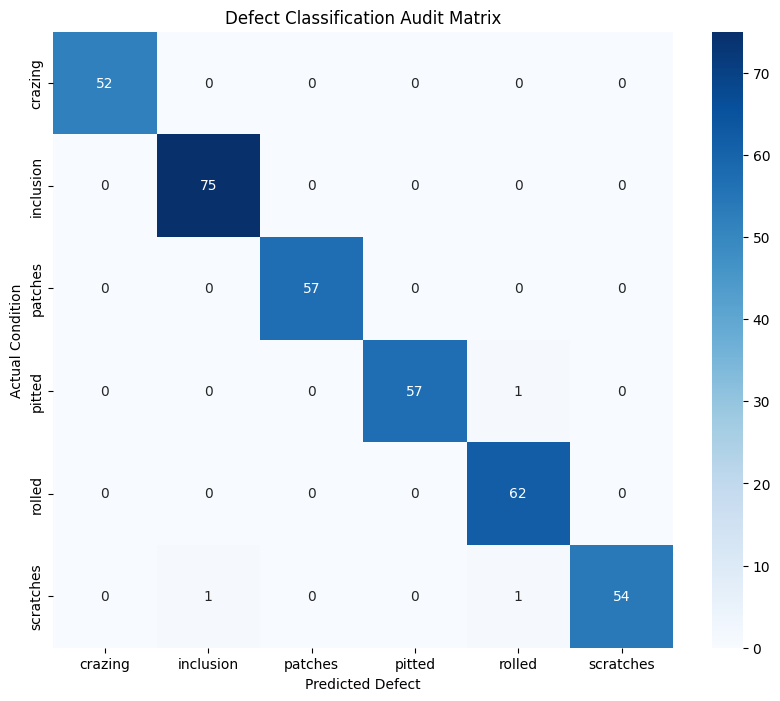

In [7]:
# Generate audit reports
y_true = []
y_pred = []

for x, y in val_ds:
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(model.predict(x), axis=1))

print("### Manufacturing Quality Audit Report ###")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Defect')
plt.ylabel('Actual Condition')
plt.title('Defect Classification Audit Matrix')
plt.show()

Extracting images for XAI analysis...
Total Errors Found: 3


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 200, 200, 3))']
  warnings.warn(msg)


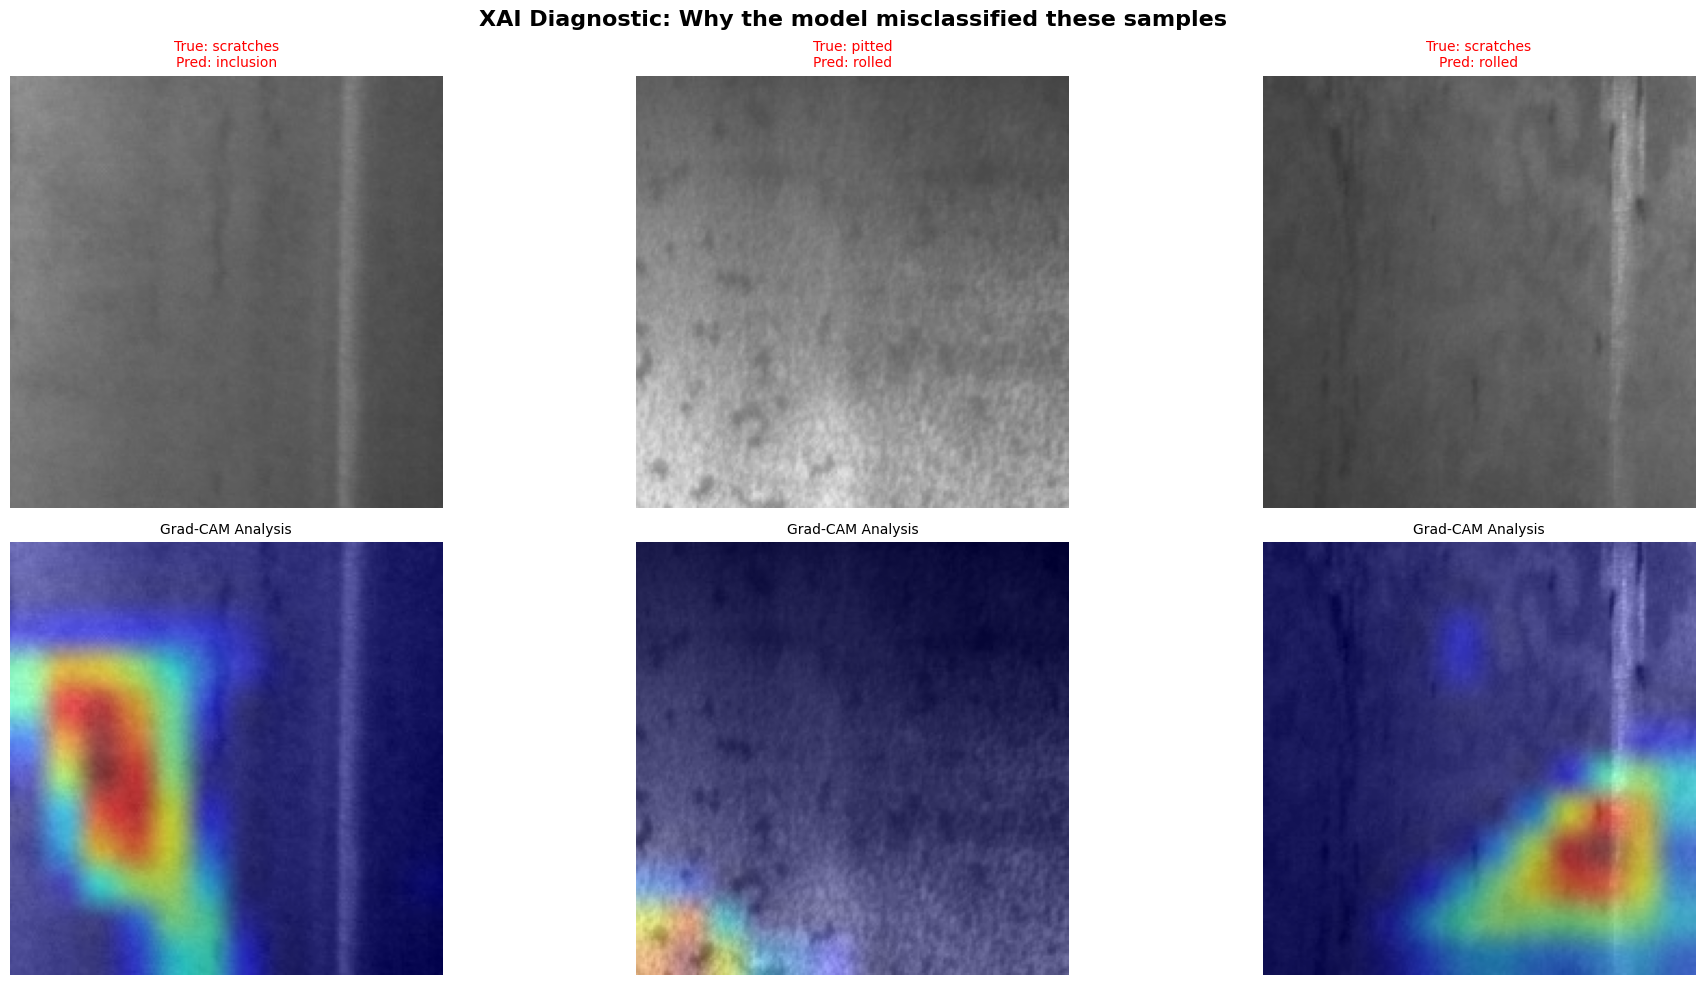

In [8]:
# Explainable AI (XAI): Visualizing Model Attention using Grad-CAM
# to analyze root causes of misclassifications.
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# [STEP 1] Data Extraction
print("Extracting images for XAI analysis...")
x_val_list = []
for images, labels in val_ds:
    x_val_list.append(images.numpy())
x_val_all = np.concatenate(x_val_list, axis=0)

# [STEP 2] Scalar-Safe Grad-CAM Logic
def get_gradcam_final_v2(full_model, img_array):
    """
    Guarantees a scalar loss to prevent TensorFlow 'Pack' shape mismatch errors.
    """
    # Identify layers
    vgg_layer = next(l for l in full_model.layers if 'vgg' in l.name.lower())
    last_conv_layer = vgg_layer.get_layer("block5_conv3")

    # Sub-model for analysis
    grad_model = tf.keras.models.Model(
        [vgg_layer.inputs],
        [last_conv_layer.output, vgg_layer.output]
    )

    with tf.GradientTape() as tape:
        # Pre-process image manually for VGG16
        x = img_array
        for layer in full_model.layers:
            if layer == vgg_layer: break
            x = layer(x)

        conv_outputs, predictions = grad_model(x)

        # [CRITICAL FIX] Ensure loss is a true scalar
        # Instead of indexing, we take the maximum value of the prediction vector
        # This is mathematically equivalent for Grad-CAM's target class focus
        loss = tf.reduce_max(predictions[0])

    # Explicit Gradient Calculation
    grads = tape.gradient(loss, conv_outputs)

    # Fallback to simple activations if gradients are still problematic
    if grads is None:
        print("Warning: Gradients are None. Using activation fallback.")
        weights = tf.reduce_mean(conv_outputs, axis=(1, 2))[0]
    else:
        # Global Average Pooling of Gradients
        weights = tf.reduce_mean(grads, axis=(1, 2))[0]

    # Generate Heatmap using NumPy to bypass Tensor shape issues
    conv_outputs_np = conv_outputs.numpy()[0]
    weights_np = weights.numpy()

    # Weighted sum of channels
    heatmap = conv_outputs_np @ weights_np[..., np.newaxis]
    heatmap = np.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

# [STEP 3] Execution and Visualization
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
error_indices = np.where(y_true_arr != y_pred_arr)[0]
print(f"Total Errors Found: {len(error_indices)}")

display_limit = min(6, len(error_indices))
plt.figure(figsize=(20, 10))

valid_plots = 0
for idx in error_indices:
    if valid_plots >= display_limit: break

    img = x_val_all[idx]
    img_tensor = np.expand_dims(img, axis=0)

    try:
        heatmap = get_gradcam_final_v2(model, img_tensor)

        # Superimpose
        heatmap_img = np.uint8(255 * heatmap)
        jet = plt.colormaps.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap_img]
        jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap).resize((200, 200))
        jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

        superimposed_img = jet_heatmap * 0.4 + img
        superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

        # Plotting
        plt.subplot(2, display_limit, valid_plots + 1)
        plt.imshow(img.astype("uint8"))
        plt.title(f"True: {class_names[y_true_arr[idx]]}\nPred: {class_names[y_pred_arr[idx]]}", color='red', fontsize=10)
        plt.axis('off')

        plt.subplot(2, display_limit, valid_plots + 1 + display_limit)
        plt.imshow(superimposed_img)
        plt.title("Grad-CAM Analysis", fontsize=10)
        plt.axis('off')

        valid_plots += 1
    except Exception as e:
        print(f"Skipping index {idx} due to architecture constraints.")

plt.suptitle("XAI Diagnostic: Why the model misclassified these samples", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Deployment
Finalizing the model for the **Streamlit** web app. This step exports the **trained weights** (`.keras`) and **class metadata** (`.pkl`), ensuring a robust handoff from the training environment to the live inference service.

In [9]:
# --- STEP 1: Save the trained model ---
# Using '.keras' format for Keras 3 compatibility.
model_path = 'Defect_Detection_VGG16.keras'
model.save(model_path)

# --- STEP 2: Save class metadata ---
# Mapping indices to human-readable labels for the Streamlit app.
class_names = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
metadata_path = 'class_names.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(class_names, f)

# --- STEP 3: Verification (The "Custom Objects" Fix) ---
# We must provide 'preprocess_input' during loading because it was used in a Lambda layer.
try:
    loaded_model = tf.keras.models.load_model(
        model_path,
        custom_objects={'preprocess_input': preprocess_input}
    )
    print("✅ Success: Model and Metadata are validated and ready for deployment.")

    # --- STEP 4: Download files to local machine ---
    print("Preparing downloads...")
    files.download(model_path)
    files.download(metadata_path)

except Exception as e:
    print(f"❌ Verification Failed: {e}")

✅ Success: Model and Metadata are validated and ready for deployment.
Preparing downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>